# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 43    |  |
| :-------------|:-------------|
| Marjoksi Elyas| 6243355 |
| Ole Doekes| 6489028 |
| Joppe van Duin| 6405835 |
| Planning Groep: 43    |Tijdstip / Tijdspanne  |
|---|---|
| Sanity checks 1/2 | 11:00-11:45|
|sanity check 3 | 11:45-12:30 |
|Tot en met fabricage |13:30-14;30  |
|Synthese sensor|14:30-15:00 |
|Kalibreren|15:00-15:30|
|Itereren/conclusie|15:30-16:00|
| Pauze 1| 12:30-13:30 |
| Pauze 2| N.V.T. |

Uitwerking formule

<img src="AfleidingDEF2.jpeg" alt="schets student 1" width="400"/>

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="Schetscondens.jpeg" alt="schets student 1" width="400"/>

In [15]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

import math

def vlakkeplaat(A, d, eps_r=1.0):
    eps0 = 8.854e-12
    eps = eps0 * eps_r
    C = eps * A / d
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [ ]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

A = 0.01
d = 0.001
eps_r = 2.3 #diëlektrische constante karton
capaciteit = vlakkeplaat(A, d, eps_r)

print(f"De capaciteit van de vlakke plaat condensator is: {capaciteit:.3e} F")


De capaciteit van de vlakke plaat condensator is: 2.036e-10 F


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](AfbCond.jpeg)
![scope meting 2](Afbscope.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 43 |2.036e-10 F | 1.023 V | 1.32 V | 1.3e-10 F|

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](Schetsen.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die massa meet.
Dat hebben we gekozen, omdat dit heel handig is om te maken met de beschikbare materialen en tijd.
Ook is het leuk om dit  te maken.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](tudelftLogo.png)


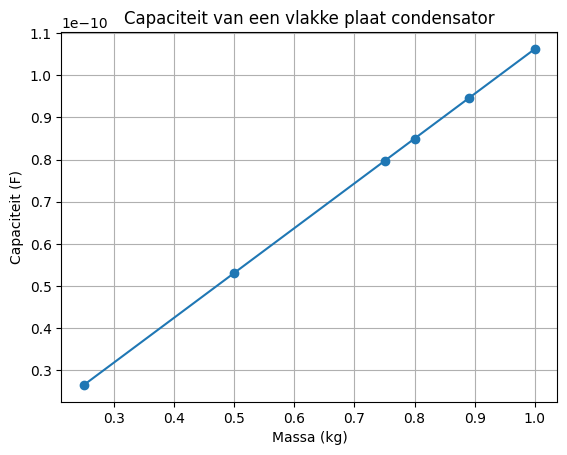

In [49]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren.
from matplotlib import pyplot as plt
import numpy as np

def vlakkeplaat(A, K, m, eps_r=1.0):
    eps0 = 8.854e-12
    eps = eps0 * eps_r
    C = eps * A*m/(K)
    return C
m = np.array([1000,890, 800, 750,500,250])*1e-3 #massa fles in gram
K = 0.001 #veerconstante in kg/m


A = 0.01 #oppervlakte in m^2
eps_r= 1.2 #diëlektrische constante van schuim door chat gegeven.
plt.figure()
plt.plot(m, vlakkeplaat(A, K, m, eps_r), marker='o')
plt.xlabel('Massa (kg)')   
plt.ylabel('Capaciteit (F)')
plt.title('Capaciteit van een vlakke plaat condensator')
plt.grid(True)
plt.show()


## Opdracht 5: Invullen tabel LTSpice.
![uitgewerkte schets](LtSpice.png)

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 0.5e-11 |26 |
| gemiddelde capaciteit| 4.5e-11 |227 |
| maximale capaciteit| 7e-11 |360 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](scopeinactie.jpeg)
![meting 2](sensorinactie.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

a = 11.618282
b = 6.235904


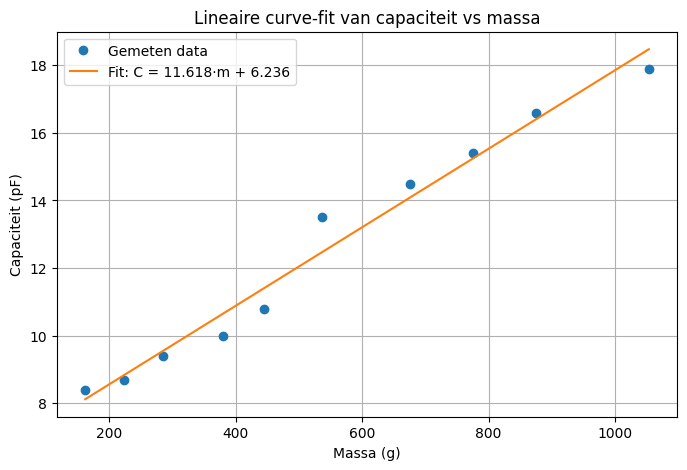

In [57]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

'''
m = np.array([215.9,428.5,868.7,971.4,1064.2]) #massa fles in gram #niet nodig
V_uit = np.array([106/2,126/2,179/2,187/2,198/2]) #gemeten spanning in mV # niet nodig
'''
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
m1 = np.array([1053.3, 874.4, 774.6, 675.4, 536.4, 444.6, 379.4, 285.3, 223.2, 162.2])  # gram
C = np.array([17.9, 16.6, 15.4, 14.5, 13.5, 10.8, 10.0, 9.4, 8.7, 8.4])  # pF

# Massa omzetten naar kg voor de fit
m1_kg = m1 / 1000

# Lineair model
def lineair(x, a, b):
    return a*x + b

# Curve-fit uitvoeren
popt, pcov = curve_fit(lineair, m1_kg, C)
a_fit, b_fit = popt

print(f"a = {a_fit:.6f}")
print(f"b = {b_fit:.6f}")

# Fit-curve maken
x_plot = np.linspace(min(m1_kg), max(m1_kg), 200)
C_fit = lineair(x_plot, a_fit, b_fit)

# Plotten (correcte assen!)
plt.figure(figsize=(8,5))
plt.plot(m1, C, 'o', label='Gemeten data')
plt.plot(x_plot*1000, C_fit, label=f'Fit: C = {a_fit:.3f}·m + {b_fit:.3f}')
plt.xlabel('Massa (g)')
plt.ylabel('Capaciteit (pF)')
plt.title('Lineaire curve-fit van capaciteit vs massa')
plt.grid(True)
plt.legend()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* verbetering 1: Het schuim had wat rechter geweest kunnen zijn, zoday de fles niet/niet gemakkelijk om kon vallen
* verbetering 2: Het schuim had iets dunner kunnen zijn, zodat de metingen duidelijker waren, met grotere getallen.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](tudelftLogo.png)

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

## Opdracht 10: Vul hieronder de conclusie in.

--

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.